<a href="https://colab.research.google.com/github/surkovaolga2005-png/python-ai-surkoa-olga/blob/main/notebooks/week3_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3: Data Visualization — визуализация и анализ данных

**Цель:** построить графики по CSV-файлу из Wikidata и сделать краткие выводы по данным.

**Данные:**

- `countries_government_development.csv` — страны, форма правления, индекс человеческого развития, население, ВВП на душу населения и континент из Wikidata.

**Что мы делаем:**

1. Клонируем репозиторий GitHub в Colab.
2. Читаем CSV-файл через pandas.
3. Переименовываем столбцы.
4. Проверяем и очищаем данные.
5. Строим графики.
6. Делаем выводы по каждому графику.# 📊 Week 3: Visualization — Визуализация

In [ ]:
# удаляем старую копию репозитория, если она уже была загружена
!rm -rf python-ai-surkoa-olga

# клонируем репозиторий из github
!git clone https://github.com/surkovaolga2005-png/python-ai-surkoa-olga

Cloning into 'python-ai-surkoa-olga'...
remote: Enumerating objects: 337, done.
remote: Counting objects: 100% (152/152), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 337 (delta 128), reused 80 (delta 80), pack-reused 185 (from 2)
Receiving objects: 100% (337/337), 1.70 MiB | 11.01 MiB/s, done.
Resolving deltas: 100% (197/197), done.


In [ ]:
# подключаем библиотеки для работы с таблицами и графиками
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# читаем csv-файл из папки data
file_path = "python-ai-surkoa-olga/data/countries_government_development.csv"

df = pd.read_csv(file_path)

df.head()

,countryLabel,governmentLabel,hdi,population,gdpPerCapita,continentLabel
0,Q139656941,монархия,NaN,NaN,NaN,NaN
1,Австралия,конституционная монархия,0.951,27614411.0,54348.23,Австралия и Океания
2,Австралия,федеративное государство,0.951,27614411.0,54348.23,Австралия и Океания
3,Австралия,представительная демократия,0.951,27614411.0,54348.23,Австралия и Океания
4,Австрия,республика,0.916,8979894.0,NaN,Европа


In [ ]:
# переименовываем столбцы для удобной работы
df = df.rename(columns={
    "countryLabel": "country",
    "governmentLabel": "form_of_government",
    "hdi": "human_development_index",
    "population": "population",
    "gdpPerCapita": "gdp_per_capita",
    "continentLabel": "continent"
})

df.head()

,country,form_of_government,human_development_index,population,gdp_per_capita,continent
0,Q139656941,монархия,NaN,NaN,NaN,NaN
1,Австралия,конституционная монархия,0.951,27614411.0,54348.23,Австралия и Океания
2,Австралия,федеративное государство,0.951,27614411.0,54348.23,Австралия и Океания
3,Австралия,представительная демократия,0.951,27614411.0,54348.23,Австралия и Океания
4,Австрия,республика,0.916,8979894.0,NaN,Европа


In [ ]:
# приводим числовые столбцы к числовому типу
df["human_development_index"] = pd.to_numeric(df["human_development_index"], errors="coerce")
df["population"] = pd.to_numeric(df["population"], errors="coerce")
df["gdp_per_capita"] = pd.to_numeric(df["gdp_per_capita"], errors="coerce")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330 entries, 0 to 329
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   country                  330 non-null    object 
 1   form_of_government       282 non-null    object 
 2   human_development_index  299 non-null    float64
 3   population               328 non-null    float64
 4   gdp_per_capita           12 non-null     float64
 5   continent                328 non-null    object 
dtypes: float64(3), object(3)
memory usage: 15.6+ KB


In [ ]:


# проверяем пропуски
df.isna().sum()

,0
country,0
form_of_government,48
human_development_index,31
population,2
gdp_per_capita,318
continent,2


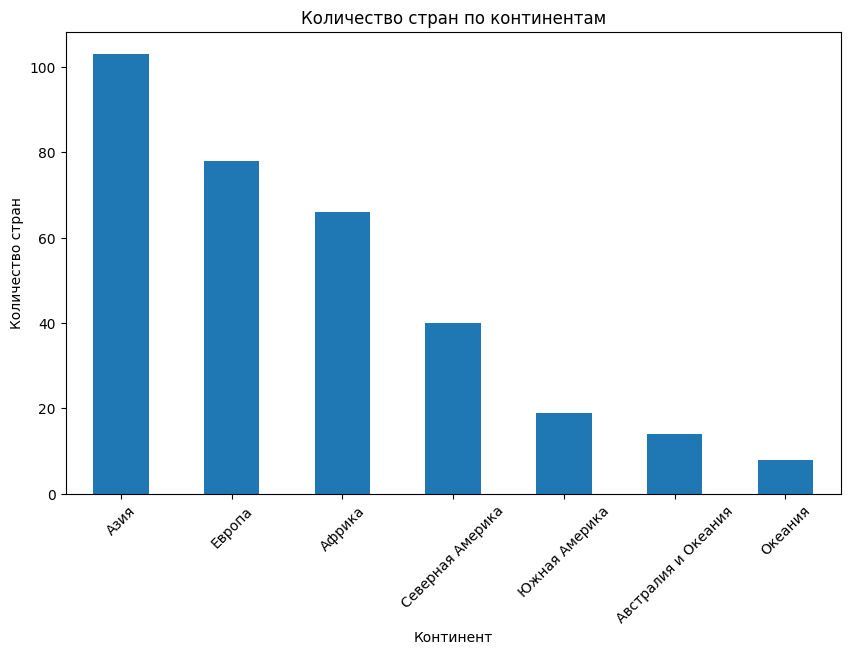

In [ ]:
# считаем количество стран по континентам
continent_counts = df["continent"].value_counts().dropna()

plt.figure(figsize=(10, 6))
continent_counts.plot(kind="bar")

plt.title("Количество стран по континентам")
plt.xlabel("Континент")
plt.ylabel("Количество стран")
plt.xticks(rotation=45)
plt.show()

По графику видно, какие континенты представлены в таблице чаще всего. Это важно учитывать при дальнейшем сравнении, потому что количество стран по континентам может быть неравномерным.

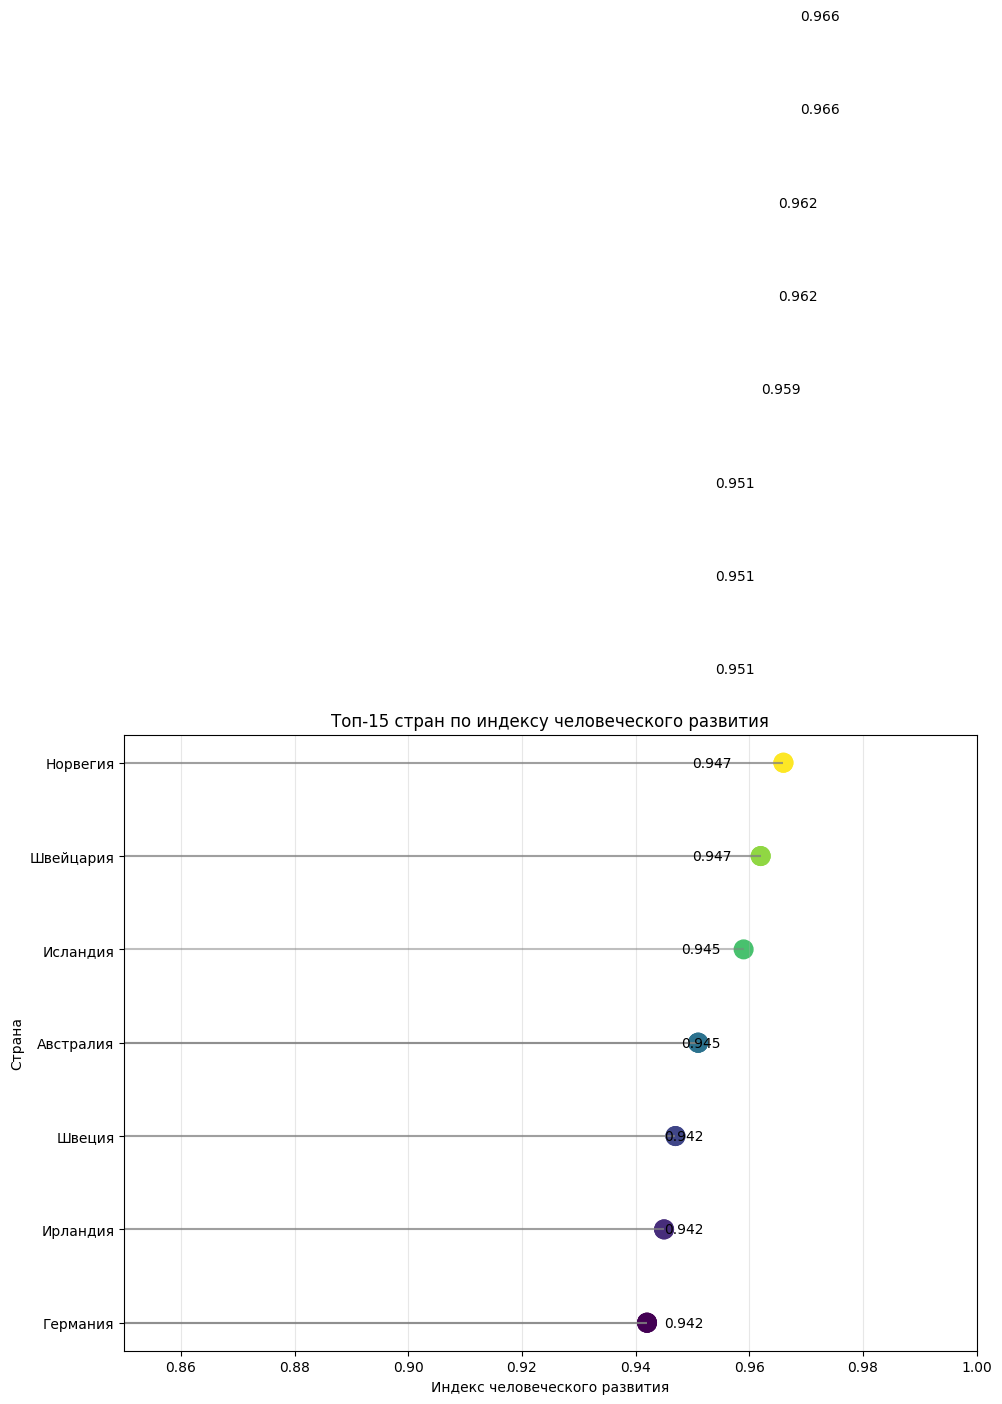

In [ ]:
# выбираем страны с заполненным индексом человеческого развития
top_hdi = df.dropna(subset=["human_development_index"])
top_hdi = top_hdi.sort_values("human_development_index", ascending=True).tail(15)

plt.figure(figsize=(11, 8))

colors = plt.cm.viridis(top_hdi["human_development_index"])

plt.hlines(
    y=top_hdi["country"],
    xmin=0,
    xmax=top_hdi["human_development_index"],
    color="gray",
    alpha=0.5
)

plt.scatter(
    top_hdi["human_development_index"],
    top_hdi["country"],
    s=180,
    c=top_hdi["human_development_index"],
    cmap="viridis"
)

for index, value in enumerate(top_hdi["human_development_index"]):
    plt.text(value + 0.003, index, round(value, 3), va="center")

plt.title("Топ-15 стран по индексу человеческого развития")
plt.xlabel("Индекс человеческого развития")
plt.ylabel("Страна")
plt.xlim(0.85, 1.0)
plt.grid(axis="x", alpha=0.3)
plt.show()

Этот график показывает страны с самым высоким индексом человеческого развития. Формат lollipop chart делает различия между странами заметнее, чем обычная таблица или простой столбчатый график.

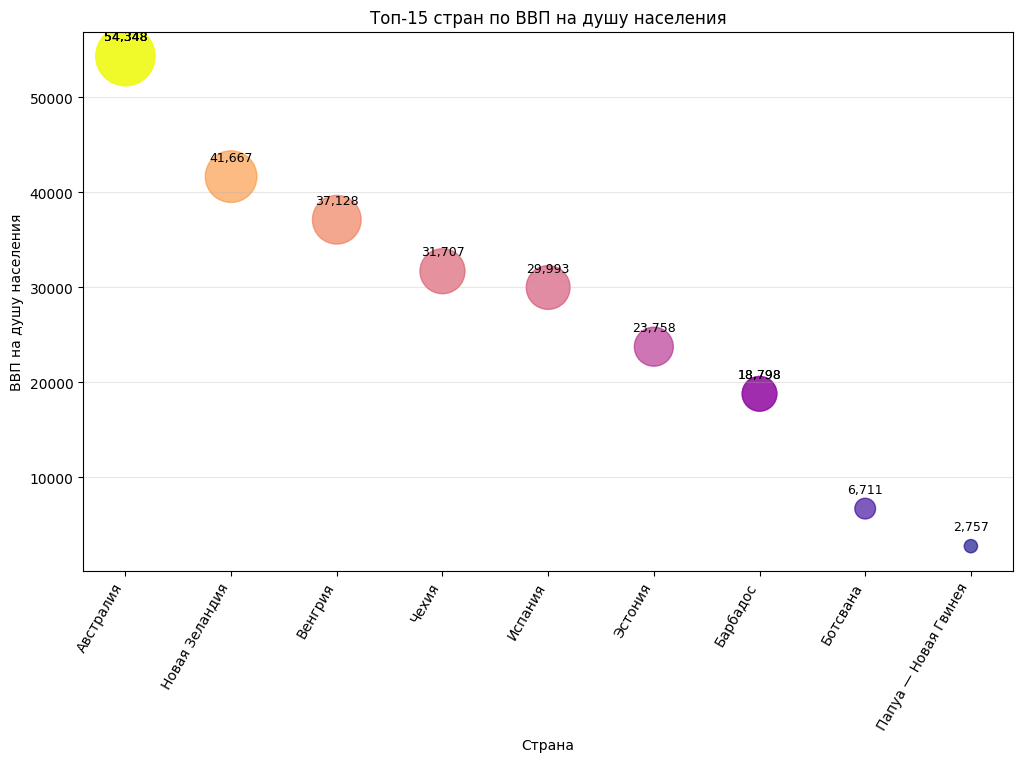

In [ ]:
# выбираем страны с заполненным ввп на душу населения
top_gdp = df.dropna(subset=["gdp_per_capita"])
top_gdp = top_gdp.sort_values("gdp_per_capita", ascending=False).head(15)

plt.figure(figsize=(12, 7))

sizes = top_gdp["gdp_per_capita"] / top_gdp["gdp_per_capita"].max() * 1800

plt.scatter(
    x=top_gdp["country"],
    y=top_gdp["gdp_per_capita"],
    s=sizes,
    alpha=0.65,
    c=top_gdp["gdp_per_capita"],
    cmap="plasma"
)

for i, row in top_gdp.iterrows():
    plt.text(
        row["country"],
        row["gdp_per_capita"] + top_gdp["gdp_per_capita"].max() * 0.03,
        f'{row["gdp_per_capita"]:,.0f}',
        ha="center",
        fontsize=9
    )

plt.title("Топ-15 стран по ВВП на душу населения")
plt.xlabel("Страна")
plt.ylabel("ВВП на душу населения")
plt.xticks(rotation=60, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.show()

Пузырьковый график показывает не только рейтинг стран по ВВП на душу населения, но и визуально усиливает различия между ними: чем больше пузырь, тем выше показатель.

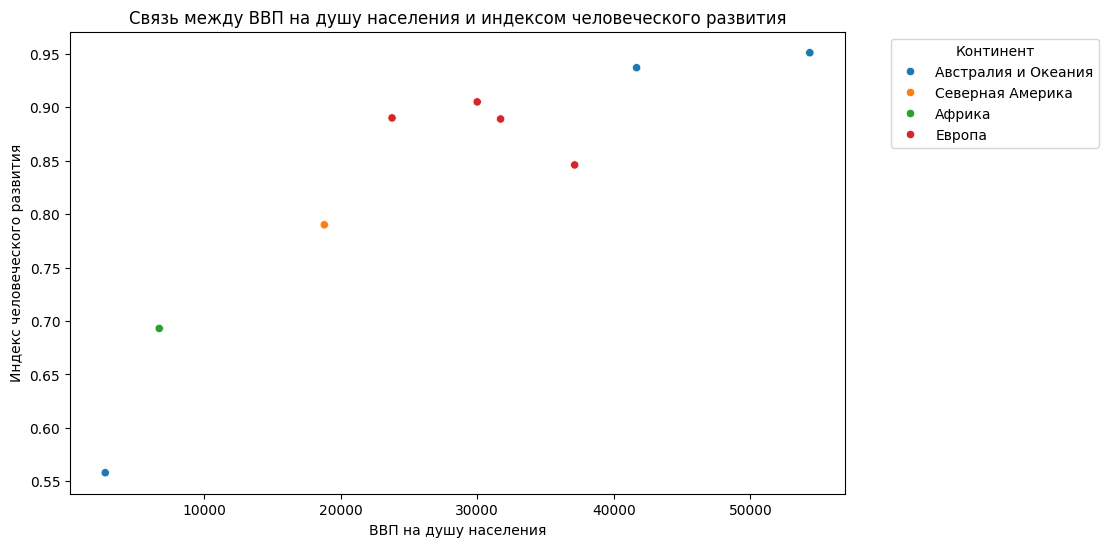

In [ ]:
# оставляем строки, где есть и ввп на душу населения, и индекс человеческого развития
scatter_data = df.dropna(subset=["gdp_per_capita", "human_development_index"])

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=scatter_data,
    x="gdp_per_capita",
    y="human_development_index",
    hue="continent"
)

plt.title("Связь между ВВП на душу населения и индексом человеческого развития")
plt.xlabel("ВВП на душу населения")
plt.ylabel("Индекс человеческого развития")
plt.legend(title="Континент", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

Диаграмма рассеяния помогает увидеть, связаны ли экономические показатели страны с индексом человеческого развития. Если точки в целом поднимаются вверх при росте ВВП на душу населения, это может говорить о положительной связи между показателями.

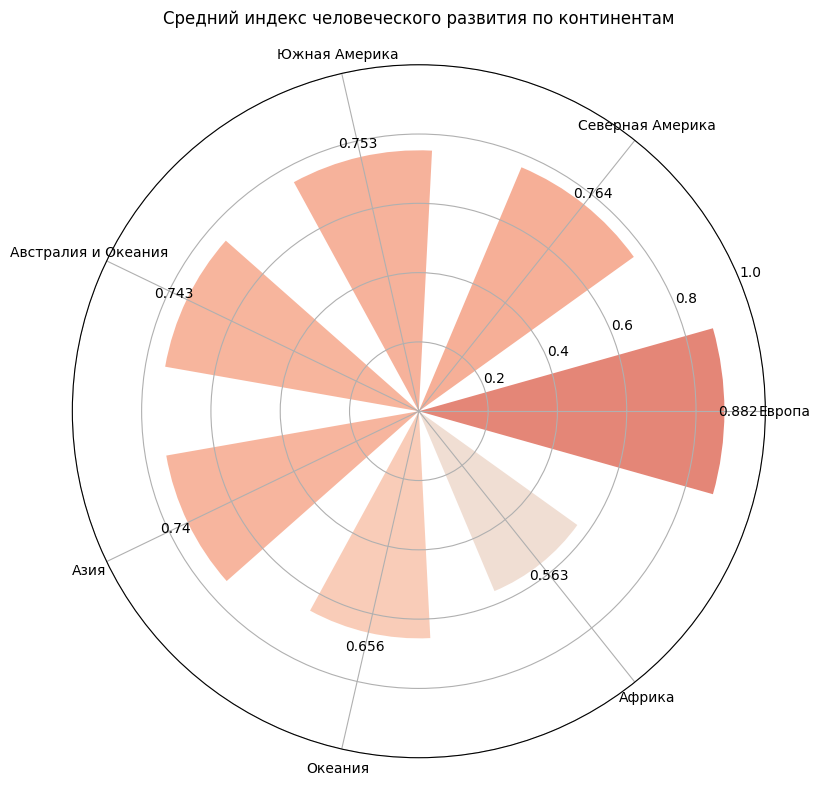

In [ ]:
# считаем средний индекс человеческого развития по континентам
mean_hdi_by_continent = (
    df.dropna(subset=["continent", "human_development_index"])
    .groupby("continent")["human_development_index"]
    .mean()
    .sort_values(ascending=False)
)

labels = mean_hdi_by_continent.index.tolist()
values = mean_hdi_by_continent.values

angles = [n / float(len(labels)) * 2 * 3.14159 for n in range(len(labels))]

plt.figure(figsize=(9, 9))
ax = plt.subplot(111, polar=True)

bars = ax.bar(
    angles,
    values,
    width=0.55,
    alpha=0.75,
    color=plt.cm.coolwarm(values)
)

ax.set_xticks(angles)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)

for angle, value, label in zip(angles, values, labels):
    ax.text(
        angle,
        value + 0.04,
        round(value, 3),
        ha="center",
        va="center",
        fontsize=10
    )

plt.title("Средний индекс человеческого развития по континентам", pad=30)
plt.show()

Круговая диаграмма позволяет необычно сравнить средний индекс человеческого развития по континентам. Чем длиннее сектор, тем выше средний показатель HDI.

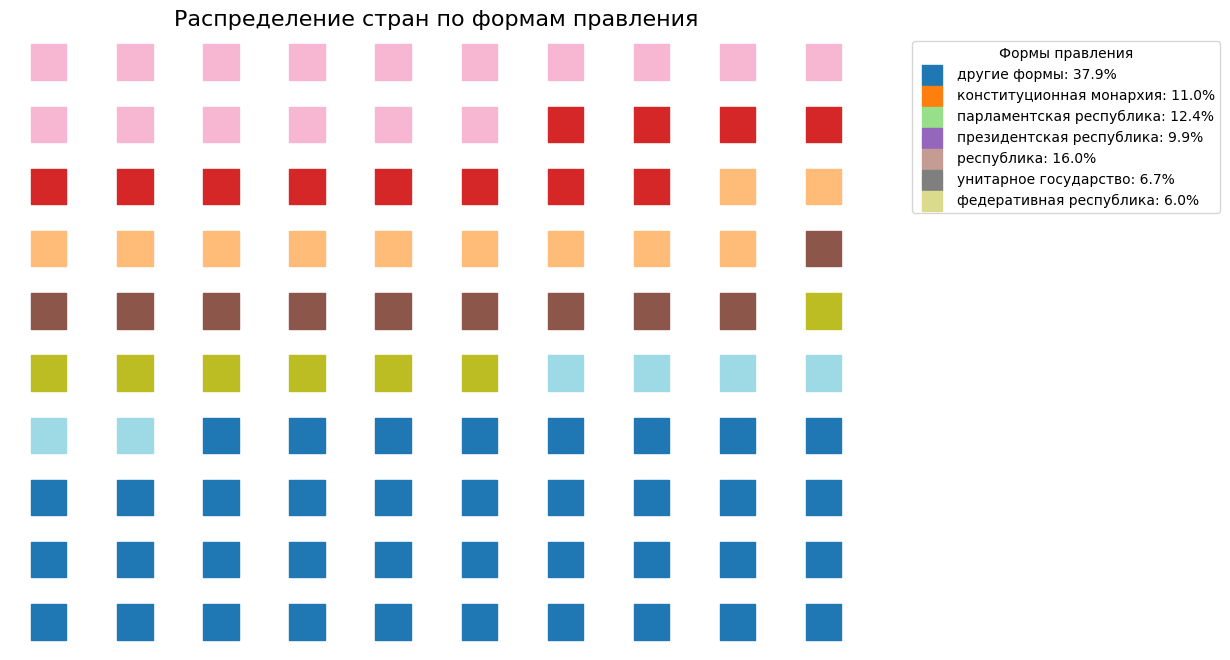

In [ ]:
# строим необычный waffle chart для самых частых форм правления
government_counts = df["form_of_government"].dropna().value_counts()

# оставляем 6 самых частых форм правления, остальные объединяем
top_governments = government_counts.head(6)
other_count = government_counts.iloc[6:].sum()

government_for_plot = top_governments.copy()
government_for_plot["другие формы"] = other_count

# создаем сетку из 100 квадратов
total_squares = 100
proportions = government_for_plot / government_for_plot.sum()
squares = (proportions * total_squares).round().astype(int)

# исправляем возможную разницу из-за округления
difference = total_squares - squares.sum()
if difference != 0:
    squares.iloc[0] += difference

waffle_data = []

for category, count in squares.items():
    waffle_data.extend([category] * count)

waffle_df = pd.DataFrame({
    "category": waffle_data,
    "x": [i % 10 for i in range(total_squares)],
    "y": [i // 10 for i in range(total_squares)]
})

category_codes = waffle_df["category"].astype("category").cat.codes

plt.figure(figsize=(11, 8))

plt.scatter(
    waffle_df["x"],
    waffle_df["y"],
    c=category_codes,
    cmap="tab20",
    s=650,
    marker="s"
)

plt.title("Распределение стран по формам правления", fontsize=16)
plt.axis("off")
plt.gca().invert_yaxis()

# создаем легенду вручную
categories = waffle_df["category"].astype("category").cat.categories

for i, category in enumerate(categories):
    percent = proportions[category] * 100
    plt.scatter([], [], c=[plt.cm.tab20(i / len(categories))], s=200, marker="s",
                label=f"{category}: {percent:.1f}%")

plt.legend(
    title="Формы правления",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()

Waffle chart показывает распределение стран по формам правления через сетку из 100 квадратов. Один квадрат примерно соответствует одному проценту выборки. Такой формат помогает быстро увидеть, какие формы правления занимают самую большую долю, а какие встречаются реже.

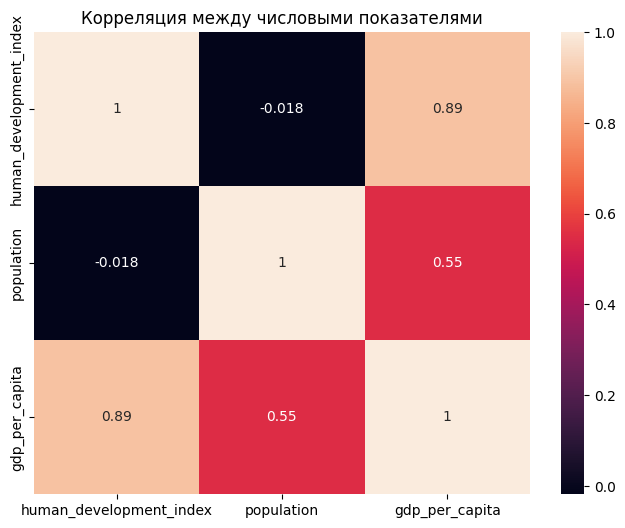

In [ ]:
# строим корреляционную матрицу для числовых столбцов
numeric_df = df[["human_development_index", "population", "gdp_per_capita"]]

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True)

plt.title("Корреляция между числовыми показателями")
plt.show()

Корреляционная матрица показывает, насколько числовые показатели связаны между собой. Особенно важно посмотреть связь между ВВП на душу населения и индексом человеческого развития.

## Итоговый вывод

В третьей части задания были построены графики по данным о странах из Wikidata. Анализ включал сравнение стран по континентам, индексу человеческого развития, ВВП на душу населения и формам правления.

Данные позволяют изучать связь между политическим устройством стран и показателями социально-экономического развития. Для дальнейшего анализа особенно полезны столбцы `form_of_government`, `human_development_index`, `gdp_per_capita` и `continent`.

Некоторые значения могут быть пропущены, так как часть свойств в SPARQL-запросе была опциональной. Это нормально для данных, полученных из Wikidata.